In [1]:
# Install required packages
%pip install numpy matplotlib seaborn tensorflow pillow --quiet

Note: you may need to restart the kernel to use updated packages.


# CIFAKE Data Exploration

## Objective
Explore the dataset - REAL vs FAKE images, class distribution, image statistics.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Configuration
PROJECT_ROOT = Path('../')
DATASET_DIR = PROJECT_ROOT / 'dataset'
REAL_DIR = DATASET_DIR / 'REAL'
FAKE_DIR = DATASET_DIR / 'FAKE'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f"Dataset location: {DATASET_DIR}")
print(f"Real images: {REAL_DIR}")
print(f"Fake images: {FAKE_DIR}")

Dataset location: ../dataset
Real images: ../dataset/REAL
Fake images: ../dataset/FAKE


In [4]:
# Count images
real_count = len([f for f in os.listdir(REAL_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(REAL_DIR) else 0
fake_count = len([f for f in os.listdir(FAKE_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(FAKE_DIR) else 0
total_count = real_count + fake_count

print(f"\n" + "="*40)
print(f"Dataset Summary")
print(f"="*40)
print(f"REAL images: {real_count}")
print(f"FAKE images: {fake_count}")
print(f"Total images: {total_count}")
if total_count > 0:
    print(f"REAL %: {real_count/total_count*100:.1f}%")
    print(f"FAKE %: {fake_count/total_count*100:.1f}%")
print(f"="*40)


Dataset Summary
REAL images: 50000
FAKE images: 50000
Total images: 100000
REAL %: 50.0%
FAKE %: 50.0%


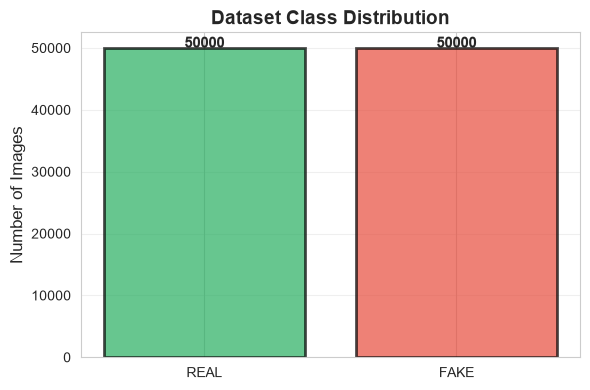

✓ Class distribution saved


In [5]:
# Plot class distribution
if total_count > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    classes = ['REAL', 'FAKE']
    counts = [real_count, fake_count]
    colors = ['#27AE60', '#E74C3C']
    
    ax.bar(classes, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (cls, cnt) in enumerate(zip(classes, counts)):
        ax.text(i, cnt + 50, str(cnt), ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Class distribution saved")
else:
    print("No images found in dataset")


Sample REAL images:


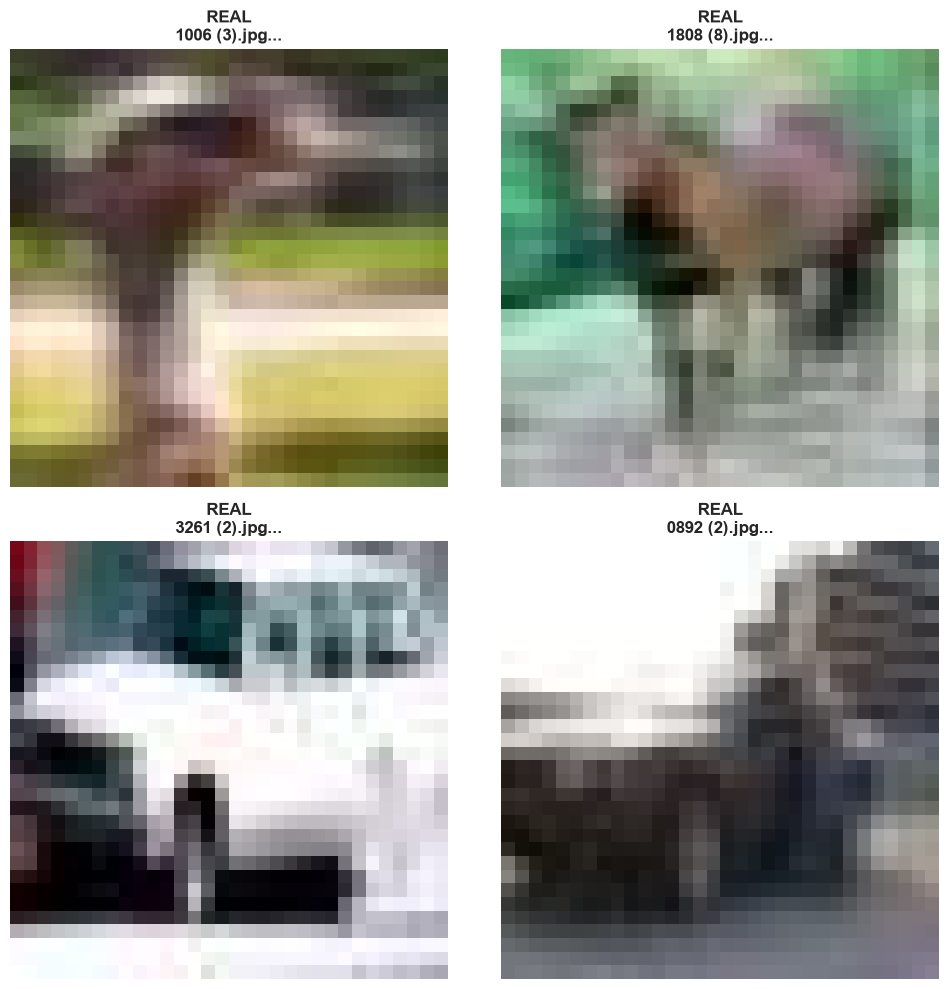

✓ Real samples saved

Sample FAKE images:


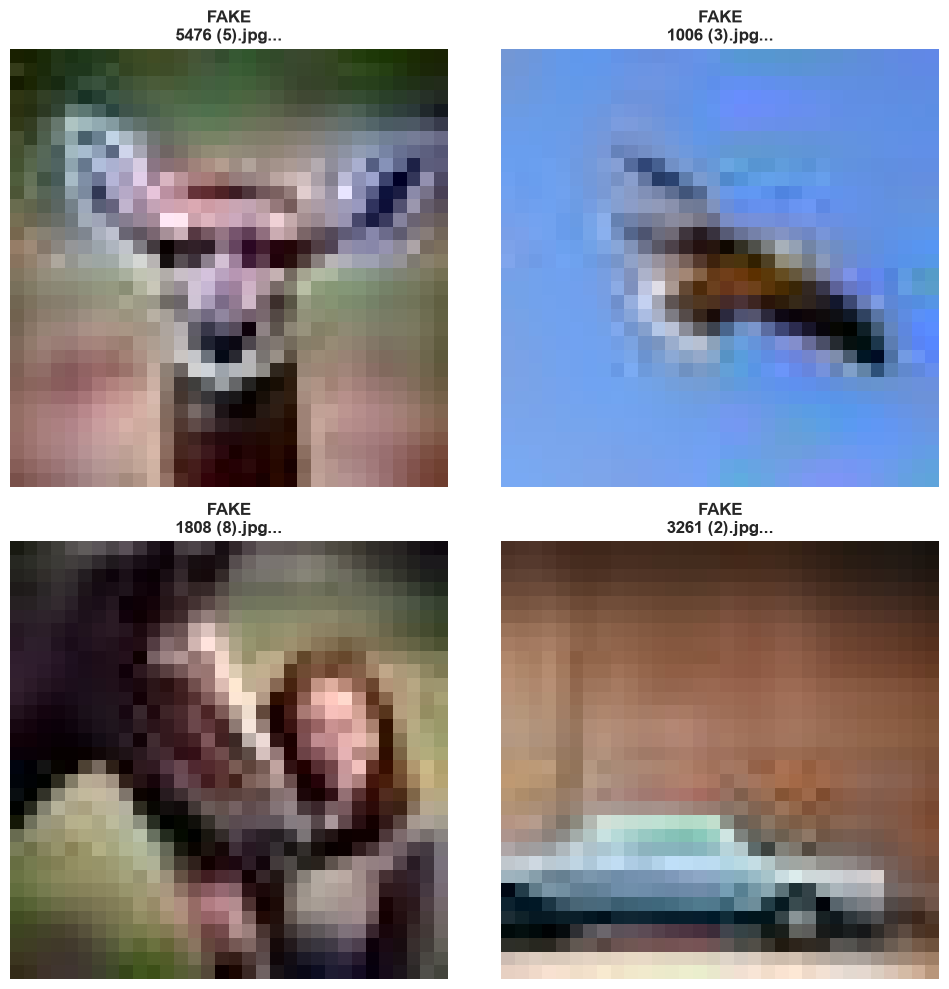

✓ Fake samples saved


In [6]:
# Load and analyze sample images
def load_and_analyze_samples(directory, label_name, num_samples=4):
    """Load and display sample images"""
    files = [f for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))]
    files = files[:num_samples]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, filename in enumerate(files):
        img_path = os.path.join(directory, filename)
        img = tf.keras.preprocessing.image.load_img(img_path)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        
        axes[i].imshow(img_array.astype('uint8'))
        axes[i].set_title(f"{label_name}\n{filename[:20]}...", fontweight='bold')
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig

if os.path.exists(REAL_DIR) and len(os.listdir(REAL_DIR)) > 0:
    print("\nSample REAL images:")
    fig_real = load_and_analyze_samples(str(REAL_DIR), 'REAL')
    plt.savefig(OUTPUTS_DIR / 'sample_real_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Real samples saved")

if os.path.exists(FAKE_DIR) and len(os.listdir(FAKE_DIR)) > 0:
    print("\nSample FAKE images:")
    fig_fake = load_and_analyze_samples(str(FAKE_DIR), 'FAKE')
    plt.savefig(OUTPUTS_DIR / 'sample_fake_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Fake samples saved")

In [7]:
# Image size analysis
def analyze_image_sizes(directory, num_samples=50):
    """Analyze image dimensions"""
    files = [f for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))]
    files = files[:num_samples]
    
    widths = []
    heights = []
    
    for filename in files:
        img_path = os.path.join(directory, filename)
        img = tf.keras.preprocessing.image.load_img(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    
    return np.array(widths), np.array(heights)

if os.path.exists(REAL_DIR) and len(os.listdir(REAL_DIR)) > 0:
    w_real, h_real = analyze_image_sizes(str(REAL_DIR))
    print(f"\nREAL image dimensions:")
    print(f"  Width: min={w_real.min()}, max={w_real.max()}, mean={w_real.mean():.0f}")
    print(f"  Height: min={h_real.min()}, max={h_real.max()}, mean={h_real.mean():.0f}")

if os.path.exists(FAKE_DIR) and len(os.listdir(FAKE_DIR)) > 0:
    w_fake, h_fake = analyze_image_sizes(str(FAKE_DIR))
    print(f"\nFAKE image dimensions:")
    print(f"  Width: min={w_fake.min()}, max={w_fake.max()}, mean={w_fake.mean():.0f}")
    print(f"  Height: min={h_fake.min()}, max={h_fake.max()}, mean={h_fake.mean():.0f}")


REAL image dimensions:
  Width: min=32, max=32, mean=32
  Height: min=32, max=32, mean=32

FAKE image dimensions:
  Width: min=32, max=32, mean=32
  Height: min=32, max=32, mean=32


In [8]:
print(f"\n✓ Data exploration complete!")
print(f"\nAll outputs saved to: {OUTPUTS_DIR}")


✓ Data exploration complete!

All outputs saved to: ../outputs
